# CXCR4 ligands - dataset from ChEMBL
- CXCR4 - chemokine receptor
- IC50 = the concentration of a drug that is required to inhibit the receptor by 50% in vitro

### Original dataset

In [1]:
import pandas as pd

df = pd.read_csv("datasets/CXCR4_chembl_ligands.csv", sep=";")
df = df[["Smiles", "Assay Type", "Molecule Name", "Molecular Weight", "AlogP", "#RO5 Violations", "Standard Type", "Standard Relation", "Standard Value", "Standard Units"]]
df.head(5)

,Smiles,Assay Type,Molecule Name,Molecular Weight,AlogP,#RO5 Violations,Standard Type,Standard Relation,Standard Value,Standard Units
0,CCCCN1C(=O)C(CC(C)C)NC(=O)C12CCN(Cc1ccc(Oc3ccc...,B,NaN,514.11,4.99,0.0,IC50,'>',10000.0,nM
1,N=C(N)NCCCN[C@H]1CSSC[C@H](C(=O)NCCc2ccc(O)cc2...,B,NaN,794.02,0.18,2.0,IC50,'=',1000.0,nM
2,N=C(N)NCCC(=O)N[C@H]1CC/C=C\CC[C@H](C(N)=O)NC(...,B,NaN,677.81,-1.14,2.0,IC50,'=',10000.0,nM
3,NCCCCN(Cc1nc2ccccc2[nH]1)[C@H]1CCCc2cccnc21,B,MAVORIXAFOR,349.48,3.58,0.0,IC50,'=',30.0,nM
4,NCCCCN(C[C@H]1Cc2ccccc2CN1CC(=O)N1CCOCC1)[C@H]...,F,NaN,491.68,2.79,0.0,IC50,'=',570.0,nM


In [2]:
print("-------------\nDataset before filtering:\n-------------")
print(df.shape)
print(df["Standard Type"].value_counts())
print(df["Standard Relation"].value_counts())
print(df["Standard Units"].value_counts())

-------------
Dataset before filtering:
-------------
(1990, 10)
Standard Type
IC50    1550
EC50     300
Ki       140
Name: count, dtype: int64
Standard Relation
'='    1512
'>'     409
'<'      24
Name: count, dtype: int64
Standard Units
nM         1918
ug.mL-1      45
Name: count, dtype: int64


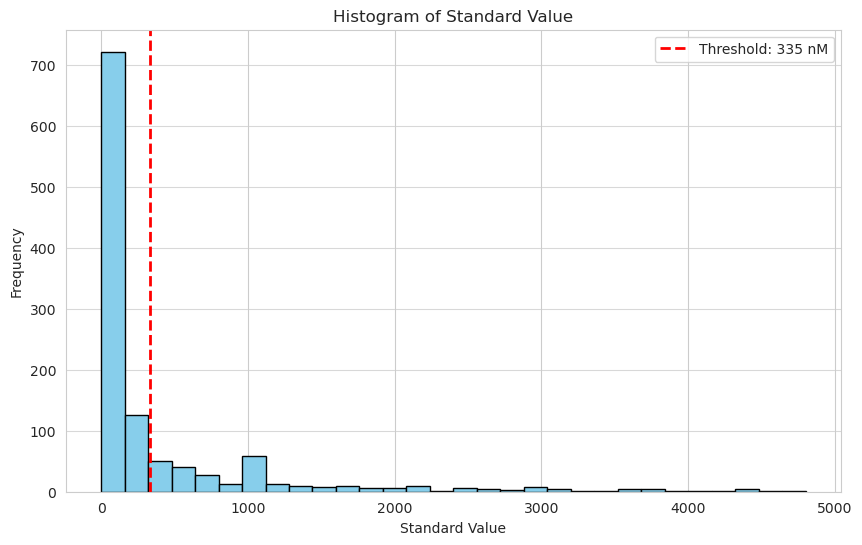

In [3]:
from plotter import plot_column_histogram
filtered = df[df['Standard Type'] == "IC50"]
plot_column_histogram(filtered[filtered['Standard Value'] < 5000], "Standard Value", threshold=335)

### Dataset filtering
- consider only IC50 (since Ki and EC50 are poorly represented)
- remove duplicates (either delete or keep average)
- new column "Inhibitor" (0/1) - active/inactive based on balanced dataset
- threshold about 200 nM - which is relevant according to Gemini:
    - "In CXCR4 drug discovery, the gold standard for a "potent" lead compound is usually $< 100\text{ nM}$, while anything $> 1,000\text{ nM}$ ($1\text{ }\mu\text{M}$) is often considered weak or inactive."

In [4]:
from source import create_balanced_cxcr4_dataset
df = df[df['Standard Type'] == "IC50"]
df_ready = create_balanced_cxcr4_dataset(df, id_col="Smiles", margin_percent=0.15)
df_ready.head(10)
# save
df_ready.to_csv("datasets/CXCR4_for_ml.csv", index=False)

----------------------------------------
CONSISTENCY & DUPLICATE ANALYSIS
----------------------------------------
Initial number of rows: 1519
Compounds averaged (diff <= 1 log unit): 102
Compounds deleted  (diff > 1 log unit):  62
Rows remaining after cleanup:      1127
----------------------------------------
FINAL DATASET SUMMARY
----------------------------------------
Active Range:      0.40 - 167.00 nM
Inactive Range:    502.00 - 225000.00 nM
Clearance Gap:     335.00 nM
Dropped Margin:    128 rows
Balanced Classes:  499 Actives / 499 Inactives
----------------------------------------


/home/rstudio/nova_slozka/PNL/project/source.py:146: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(id_col, group_keys=False).apply(process_duplicates).reset_index(drop=True)


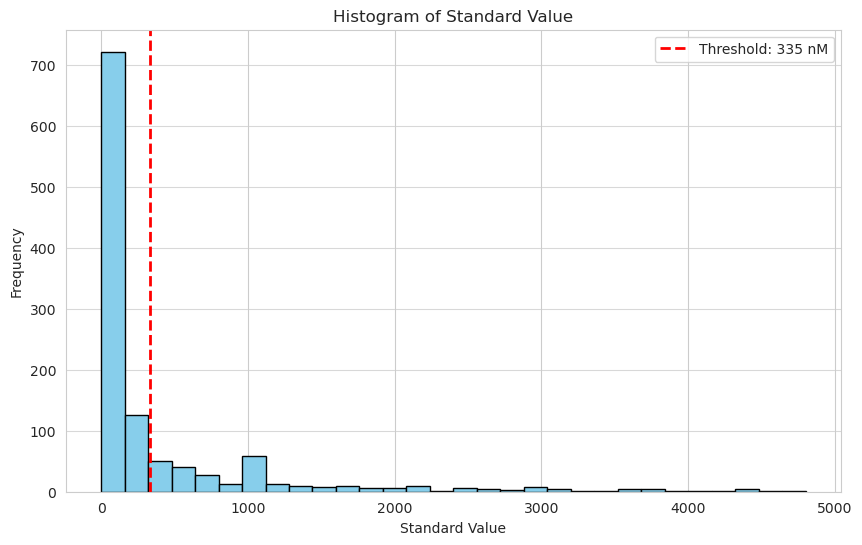

In [5]:
plot_column_histogram(df_ready[df_ready['Standard Value'] < 5000], "Standard Value", threshold=335)

And we get quite a balanced dataset - yay!

### Feature calculation

In [6]:
from source import extract_descriptors
df, descriptors = extract_descriptors(df_ready, smiles_col="Original Smiles")

### Fingerprints
- EXFP from RDKIT

In [12]:
from source_scaffolds import extract_morgan_fingerprints

df_fp, cols_fp = extract_morgan_fingerprints(df, smiles_col='Smiles', radius=2, n_bits=1024)
df_fp['Inhibitor'] = df_ready['Inhibitor']

### Scaffold extraction

In [16]:
from source_scaffolds import get_scaffolds, draw_scaffolds, draw_clusters

df, scaffolds = get_scaffolds(df, smiles_col='Smiles')

In [19]:
df_fp_scaff, fp_scaff = extract_morgan_fingerprints(df[scaffolds], smiles_col='Scaffold', radius=2, n_bits=1024)
df_fp_scaff['Inhibitor'] = df_ready['Inhibitor']

Top 6 Scaffolds


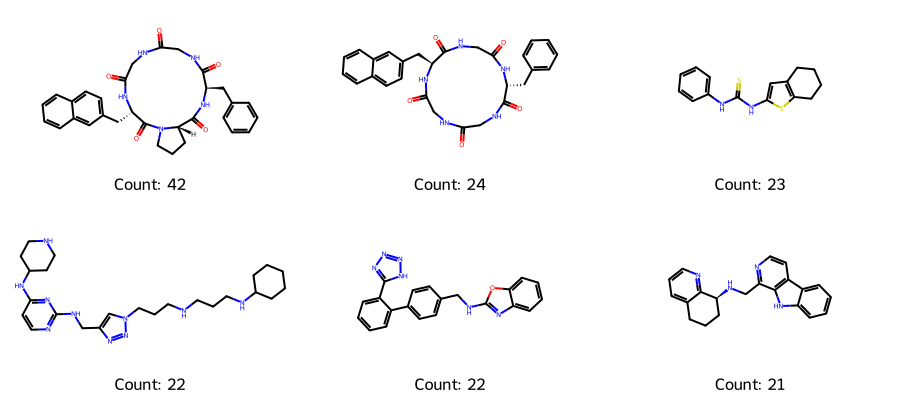

Top 6 Generic Scaffolds


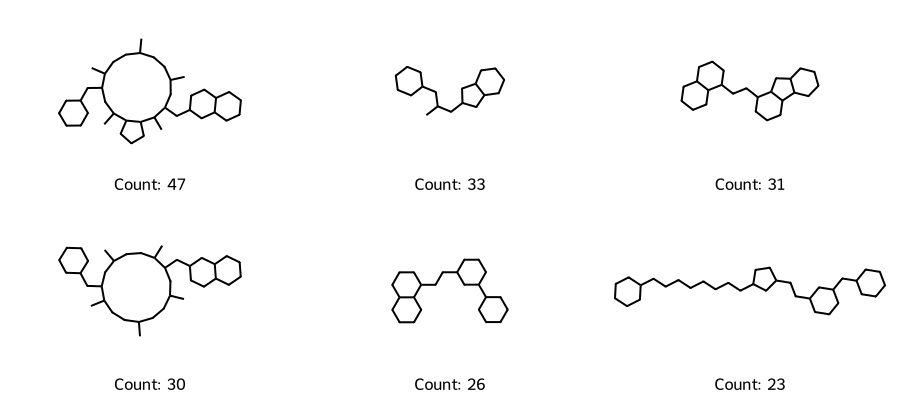

In [17]:
for scaff_col in scaffolds:
    print(f'Top 6 {scaff_col}s')
    draw_scaffolds(df, scaff_col)

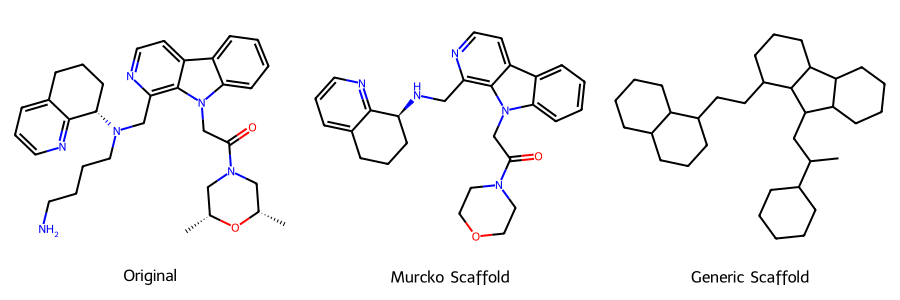

In [10]:
from source import draw_scaffold_comparison

draw_scaffold_comparison(df, 0)

### tSNE and PCA
- 3 variants:
    - one only with the fingerprints
    - one with all the features (descriptors)
    - one only with the scaffolds

/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


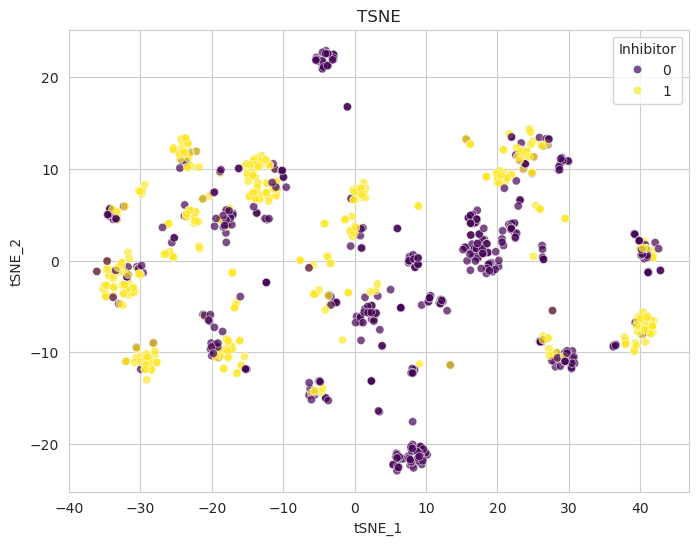

None

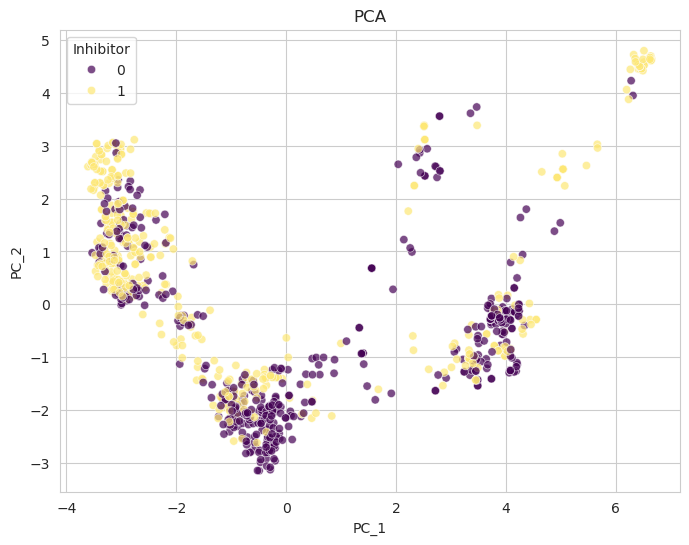

In [14]:
display(draw_clusters(df_fp, method='tsne', n_components=2, perplexity=50, colors=['#440254', '#fde725']))
draw_clusters(df_fp, method='pca', n_components=2, perplexity=50, colors=['#440254', '#fde775'])

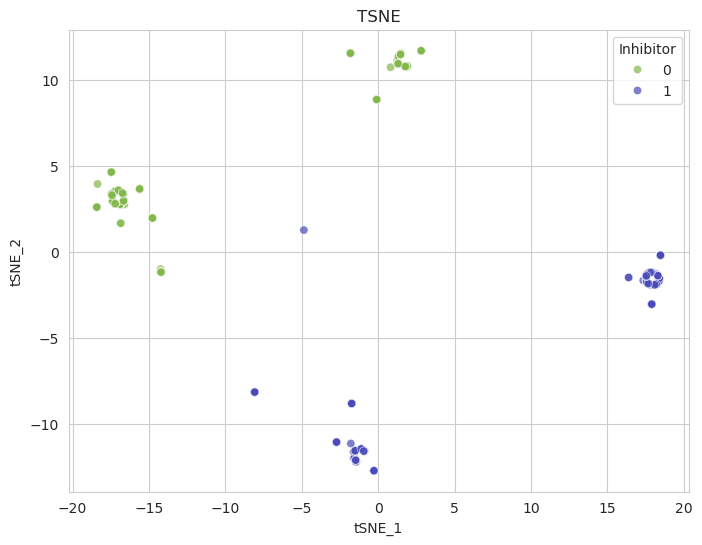

None

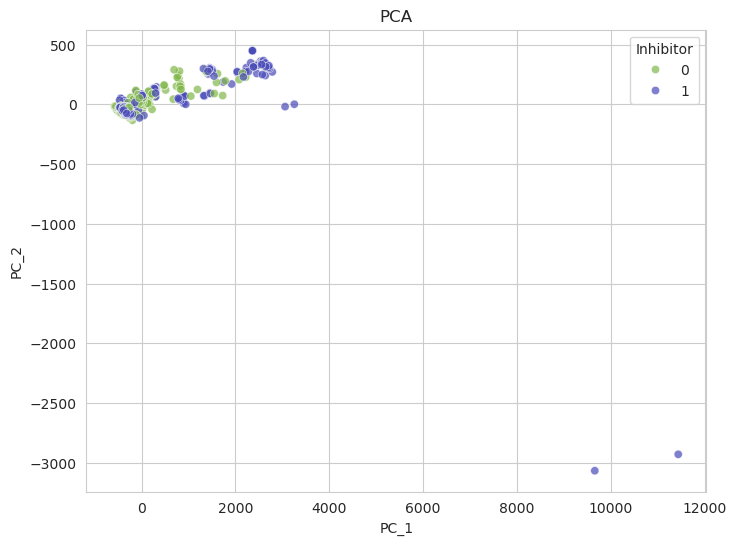

In [15]:
display(draw_clusters(df[descriptors+['Inhibitor']], method='tsne', n_components=2, perplexity=50, colors=['#81B849', '#494BB8']))
draw_clusters(df[descriptors+['Inhibitor']], method='pca', n_components=2, perplexity=50, colors=['#81B849', '#494BB8'])

/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


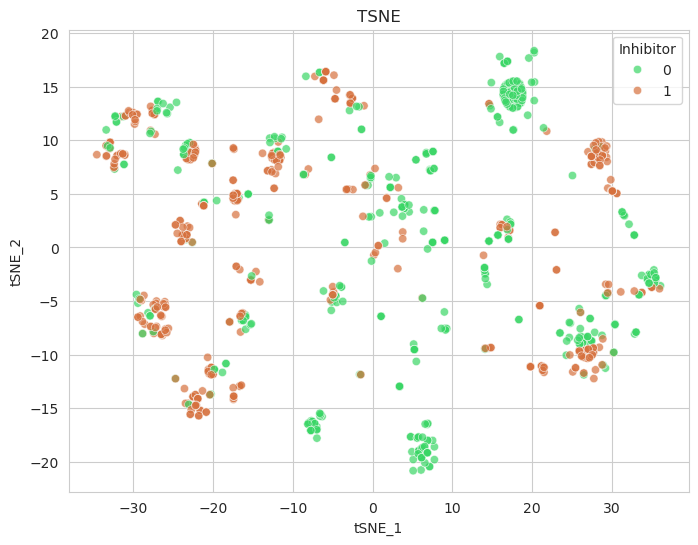

None

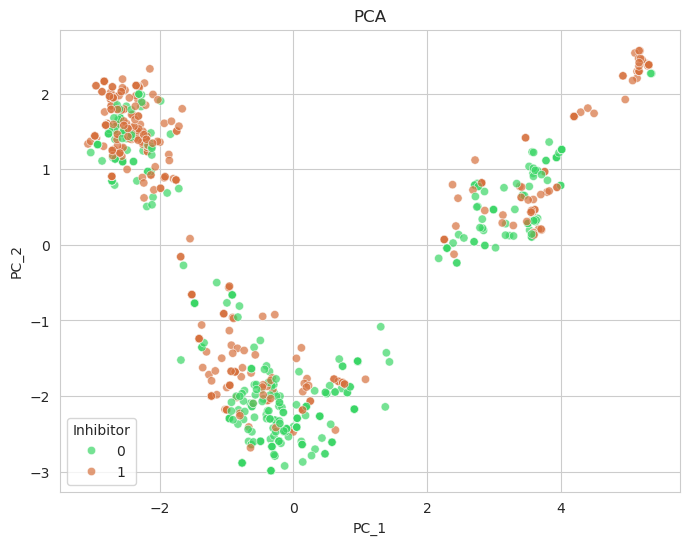

In [20]:
display(draw_clusters(df_fp_scaff, method='tsne', n_components=2, perplexity=50, colors=['#3AD666', '#D6713E']))
draw_clusters(df_fp_scaff, method='pca', n_components=2, perplexity=50, colors=['#3AD666', '#D6713E'])

### ML

In [24]:
from train_model import prepare_data, train_RF, train_KNN, train_logistic_regression, train_ridge_regression, evaluate_model, train_XGB, plot_roc_auc, plot_feature_importance

In [23]:
train_X, train_y, test_X, test_y = prepare_data(df, target_col='Inhibitor', feature_cols=descriptors)
rf_model = train_RF(train_X, train_y)
evaluate_model(rf_model, test_X, test_y)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Final Model Accuracy: 0.8250
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.81       100
           1       0.79      0.88      0.83       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



In [12]:
knn_model = train_KNN(train_X, train_y)
evaluate_model(knn_model, test_X, test_y)

Best Parameters: {'n_neighbors': 1}
Final Model Accuracy: 0.7800
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77       100
           1       0.76      0.81      0.79       100

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200



In [13]:
lr_model = train_logistic_regression(train_X, train_y)
evaluate_model(lr_model, test_X, test_y)

Best Parameters: {'lr__C': 10, 'lr__l1_ratio': 0.01}
Final Model Accuracy: 0.7650
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       100
           1       0.78      0.73      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



In [14]:
ridge_model = train_ridge_regression(train_X, train_y)
evaluate_model(ridge_model, test_X, test_y)

Best Parameters: {'lr__C': 10}
Final Model Accuracy: 0.7650
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       100
           1       0.78      0.73      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



In [15]:
from train_model import train_XGB

xgb_model = train_XGB(train_X, train_y)
evaluate_model(xgb_model, test_X, test_y)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
Final Model Accuracy: 0.8100
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       100
           1       0.79      0.84      0.82       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



### ROC AUC & Feature Importance

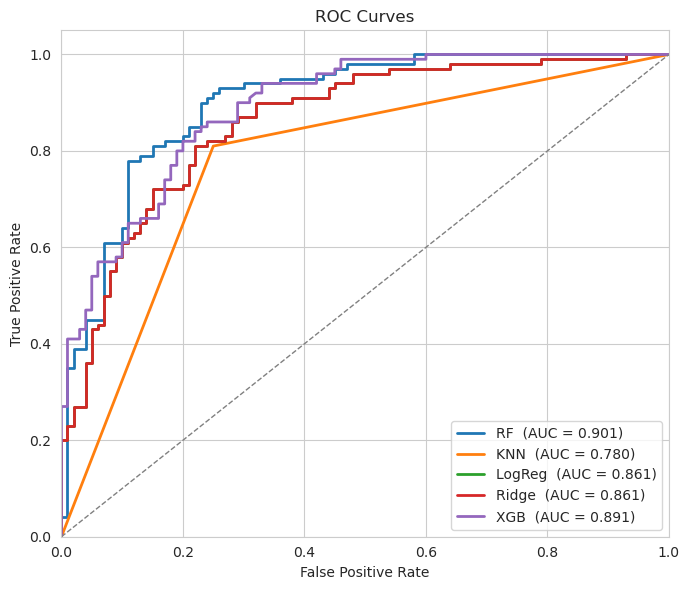

In [16]:
from train_model import plot_roc_auc, plot_feature_importance

models = {
    "RF": rf_model,
    "KNN": knn_model,
    "LogReg": lr_model,
    "Ridge": ridge_model,
    "XGB": xgb_model,
}
plot_roc_auc(models, test_X, test_y)

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (8,) and arg 3 with shape (10,).

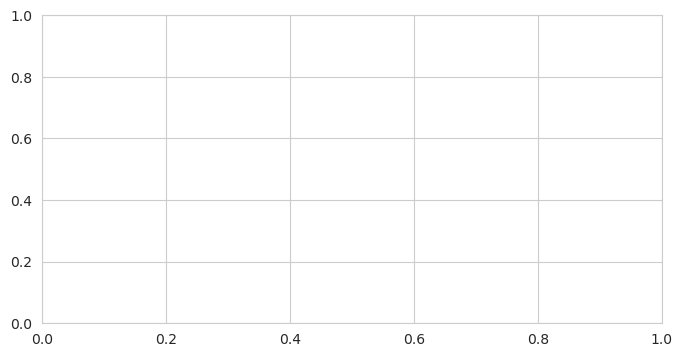

In [17]:
plot_feature_importance(rf_model, descriptors)
plot_feature_importance(xgb_model, descriptors)

### ML For Fingerprints

In [25]:
train_X, train_y, test_X, test_y = prepare_data(df_fp, target_col='Inhibitor', feature_cols=cols_fp)

### 1. Random Forest

In [26]:
rf_model = train_RF(train_X, train_y)
evaluate_model(rf_model, test_X, test_y)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Final Model Accuracy: 0.9000
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       100
           1       0.88      0.92      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



### 2. kNN

In [27]:
knn_model = train_KNN(train_X, train_y)
evaluate_model(knn_model, test_X, test_y)

Best Parameters: {'n_neighbors': 1}
Final Model Accuracy: 0.8450
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       100
           1       0.83      0.86      0.85       100

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



### 3. Linear Regression

In [28]:
lr_model = train_logistic_regression(train_X, train_y)
evaluate_model(lr_model, test_X, test_y)

/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jovyan/my

Best Parameters: {'lr__C': 0.01, 'lr__l1_ratio': 0.1}
Final Model Accuracy: 0.9150
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       100
           1       0.91      0.92      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



### 4. Ridge Regression

In [29]:
ridge_model = train_ridge_regression(train_X, train_y)
evaluate_model(ridge_model, test_X, test_y)

/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jovyan/my-conda-envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Parameters: {'lr__C': 0.01}
Final Model Accuracy: 0.9050
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       100
           1       0.92      0.89      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



### 5. XBoost

In [30]:
xgb_model = train_XGB(train_X, train_y)
evaluate_model(xgb_model, test_X, test_y)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Final Model Accuracy: 0.9100
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       100
           1       0.89      0.93      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



### ROC AUC & Feature Importance For Fingerprints

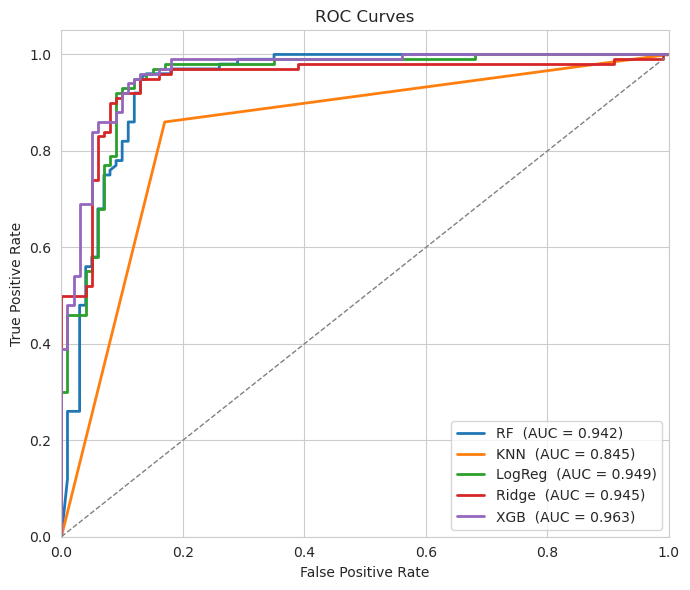

In [31]:

models = {
    "RF": rf_model,
    "KNN": knn_model,
    "LogReg": lr_model,
    "Ridge": ridge_model,
    "XGB": xgb_model,
}
plot_roc_auc(models, test_X, test_y)